# Lab Assignment: Data Quality & Data Cleaning for Data Warehouse

**สถานการณ์:** คุณเป็น Data Engineer ของร้านค้าออนไลน์ และได้รับไฟล์ `e_commerce_raw.csv` ที่ต้องเตรียมก่อนโหลดเข้าสู่ Data Warehouse  
**เป้าหมาย:** สำรวจปัญหาคุณภาพข้อมูล ออกแบบกฎการทำความสะอาด และส่งออกข้อมูลที่พร้อมใช้งาน

> ห้ามลบข้อมูลผิดปกติโดยไม่อธิบายเหตุผล ต้องพิจารณา Business Context โดยเฉพาะรายการโปรโมชัน


## ผลลัพธ์การเรียนรู้
1. ตรวจสอบข้อมูลด้วย `info()`, `isnull()`, `describe()` และ `duplicated()`
2. เชื่อมโยงปัญหากับ 6 มิติ: Accuracy, Completeness, Consistency, Uniqueness, Timeliness, Validity
3. จัดการ Missing Values และรูปแบบข้อมูลที่ไม่สอดคล้อง
4. ตรวจจับ Outlier ด้วย IQR และทำ Capping อย่างมีเหตุผล
5. สร้างไฟล์ Clean Data และรายงาน Data Quality ก่อน–หลัง


## 0) เตรียมระบบและอ่านข้อมูล

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path('/content/e_commerce_raw.csv')   # path ตรงจุดที่อัปโหลด
OUTPUT_DIR = Path('/content/outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 50)
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()
print('Shape:', df.shape)
df.head()

Shape: (630, 16)


,Transaction_ID,Customer_ID,Customer_Name,Customer_Email,Gender,Province,Order_Date,Load_Timestamp,Product_Category,Quantity,Unit_Price,Discount_Rate,Transaction_Amount,Payment_Method,Order_Status,Is_Promotion
0,T000127,C0103,Tee Phromla,tee.phromla103@example.com,female,Phuket,2026-06-11,2026-06-11 05:00:00,Sports,3,110.26,0.05,314.24,PP,Cancelled,N
1,T000169,C0138,Mint Dechawat,mint.dechawat138@example.com,M,Khon Kaen,2026-01-24,2026-01-24 01:00:00,Home,3,138.08,0.05,393.53,PromptPay,Processing,N
2,T000003,C0071,Aom Sukjai,aom.sukjai71@example.com,m,Chanthaburi,05/29/2026,2026-05-29 05:00:00,Home,4,263.93,0.00,1055.72,COD,Cancelled,N
3,T000336,C0152,Tee Dechawat,tee.dechawat152@example.com,male,Chanthaburi,02/01/2026,2026-02-01 18:00:00,Food,6,116.53,0.10,629.26,Transfer,Returned,N
4,T000093,C0090,Mook Sukjai,mook.sukjai90@example.com,M,Chanthaburi,2026-04-18,2026-04-18 13:00:00,Electronics,5,358.35,0.00,1791.75,promptpay,Processing,N


## 1) Data Profiling

ให้แสดงผลต่อไปนี้และเขียนข้อสังเกตใต้เซลล์
- โครงสร้างและชนิดข้อมูล
- จำนวน Missing Values รายคอลัมน์
- สถิติเชิงพรรณนาของข้อมูลตัวเลข
- จำนวนแถวซ้ำทั้งแถว
- จำนวนค่าที่แตกต่างในคอลัมน์สำคัญ


In [2]:
# TODO 1: Data Profiling
print(df.info())

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nDescriptive statistics (numeric columns):")
print(df.describe(include='number'))

print("\nFull-row duplicates:", df.duplicated().sum())

for col in ['Gender', 'Payment_Method', 'Order_Status', 'Province', 'Is_Promotion']:
    if col in df.columns:
        print(f"\nUnique values in {col}:")
        print(df[col].value_counts(dropna=False))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630 entries, 0 to 629
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction_ID      630 non-null    object 
 1   Customer_ID         630 non-null    object 
 2   Customer_Name       630 non-null    object 
 3   Customer_Email      580 non-null    object 
 4   Gender              630 non-null    object 
 5   Province            618 non-null    object 
 6   Order_Date          630 non-null    object 
 7   Load_Timestamp      630 non-null    object 
 8   Product_Category    630 non-null    object 
 9   Quantity            630 non-null    int64  
 10  Unit_Price          630 non-null    float64
 11  Discount_Rate       630 non-null    float64
 12  Transaction_Amount  630 non-null    float64
 13  Payment_Method      630 non-null    object 
 14  Order_Status        630 non-null    object 
 15  Is_Promotion        630 non-null    object 
dtypes: float

### คำถาม 1
ระบุปัญหาที่พบอย่างน้อย **5 ปัญหา** และจับคู่กับมิติ Data Quality อย่างน้อย **3 มิติ**

| ปัญหาที่พบ | คอลัมน์ | มิติ Data Quality | หลักฐาน/จำนวนแถว |
|---|---|---|---|
| | | | |

**หมายเหตุ:** ตารางด้านบนเป็นแม่แบบ ให้เติมผลลัพธ์จริงจากการรัน TODO 1 เช่น

| ปัญหาที่พบ | คอลัมน์ | มิติ Data Quality | หลักฐาน/จำนวนแถว |
|---|---|---|---|
| Email หายไปบางแถว | Customer_Email | Completeness | จำนวนจาก `isnull().sum()` |
| รูปแบบเพศไม่สอดคล้อง (M/Male/ชาย ฯลฯ) | Gender | Consistency | จำนวนค่าที่ไม่ซ้ำจาก `value_counts()` |
| วันที่หลายรูปแบบ/ตีความกำกวม | Order_Date | Consistency / Validity | ตัวอย่างรูปแบบที่พบ |
| แถวซ้ำทั้งแถว | ทุกคอลัมน์ | Uniqueness | ผลจาก `duplicated().sum()` |
| Transaction_Amount ไม่ตรงสูตรคำนวณ | Transaction_Amount | Accuracy | ผลจาก Accuracy_Flag ใน TODO 5.3 |
| โหลดข้อมูลล่าช้ากว่า 24 ชม. | Load_Timestamp vs Order_Date | Timeliness | ผลจาก Late_Load_Flag ใน TODO 7 |


## 2) Completeness: จัดการ Missing Values

In [3]:
# TODO 2.1: ตรวจสอบ Customer_Email และ Province ที่หายไป
print("Missing Customer_Email:", df['Customer_Email'].isnull().sum())
print("Missing Province:", df['Province'].isnull().sum())

# TODO 2.2: เติม Customer_Email ด้วย unknown-member placeholder + flag เพื่อย้อนตรวจสอบได้
df['Email_Missing_Flag'] = df['Customer_Email'].isnull()
df['Customer_Email'] = df['Customer_Email'].fillna('unknown_member@placeholder.local')

# TODO 2.3: เติม Province ที่หายเป็น 'Unknown' พร้อม flag
df['Province_Missing_Flag'] = df['Province'].isnull()
df['Province'] = df['Province'].fillna('Unknown')

print(df[['Customer_Email', 'Email_Missing_Flag', 'Province', 'Province_Missing_Flag']].head())


Missing Customer_Email: 50
Missing Province: 12
                 Customer_Email  Email_Missing_Flag     Province  \
0    tee.phromla103@example.com               False       Phuket   
1  mint.dechawat138@example.com               False    Khon Kaen   
2      aom.sukjai71@example.com               False  Chanthaburi   
3   tee.dechawat152@example.com               False  Chanthaburi   
4     mook.sukjai90@example.com               False  Chanthaburi   

   Province_Missing_Flag  
0                  False  
1                  False  
2                  False  
3                  False  
4                  False  


### คำถาม 2
อธิบายว่าเหตุใดการใช้ dropna() กับ Customer_Email อาจทำให้ยอดขายรวมใน Data Warehouse ผิดเพี้ยน และเหตุใดการเติมค่าเฉลี่ยจึงไม่เหมาะกับข้อมูลประเภทอีเมล

เพราะว่าถ้า dropna กับ Customer_Email จะทำให้คนๆนั้นหายไปทั้งหมดเลย และ ที่การเติมค่าเฉลี่ย ไม่เหมาะกับช้อมูลปนะเภทอีเมบเพราะ อีเมลนั้นไม่ใช่ตัวเลขแต่อีเมลเป็นของคนๆนั้น จึงไม่สามารถหาค่าเฉลี่ยมาแทนอีเมล
กันได้


## 3) Consistency: จัดรูปแบบข้อมูลให้เป็นมาตรฐาน

In [4]:
# TODO 3.1: Standardize Gender ให้เหลือ M, F, Unknown
gender_map = {
    'm': 'M', 'male': 'M', 'ชาย': 'M',
    'f': 'F', 'female': 'F', 'หญิง': 'F',
}
df['Gender'] = (df['Gender'].astype(str).str.strip().str.lower()
                .map(gender_map).fillna('Unknown'))

# TODO 3.2: Standardize Payment_Method
payment_map = {
    'credit card': 'Credit Card', 'creditcard': 'Credit Card', 'cc': 'Credit Card', 'บัตรเครดิต': 'Credit Card',
    'promptpay': 'PromptPay', 'prompt pay': 'PromptPay', 'พร้อมเพย์': 'PromptPay',
    'cod': 'Cash on Delivery', 'cash on delivery': 'Cash on Delivery', 'เก็บเงินปลายทาง': 'Cash on Delivery',
    'bank transfer': 'Bank Transfer', 'transfer': 'Bank Transfer', 'โอนเงิน': 'Bank Transfer',
}
df['Payment_Method'] = (df['Payment_Method'].astype(str).str.strip().str.lower()
                         .map(payment_map).fillna('Unknown'))

# TODO 3.3: แปลง Order_Date เป็น YYYY-MM-DD โดยใช้ Load_Timestamp ช่วยตัดสินความกำกวม
from datetime import datetime

df['Load_Timestamp'] = pd.to_datetime(df['Load_Timestamp'], errors='coerce')

def parse_order_date(raw, load_ts):
    if pd.isnull(raw):
        return pd.NaT, True
    raw = str(raw).strip()
    for fmt in ('%Y-%m-%d', '%Y/%m/%d'):
        try:
            return datetime.strptime(raw, fmt), False
        except ValueError:
            pass
    candidates = []
    for fmt in ('%d/%m/%Y', '%m/%d/%Y', '%d-%m-%Y', '%m-%d-%Y'):
        try:
            candidates.append(datetime.strptime(raw, fmt))
        except ValueError:
            pass
    if not candidates:
        return pd.NaT, True
    unique_candidates = list({c for c in candidates})
    if len(unique_candidates) == 1:
        return unique_candidates[0], False
    # กำกวม: เลือกวันที่ที่ใกล้กับ Load_Timestamp มากที่สุด และไม่เกิด "หลัง" เวลาโหลด
    if pd.notnull(load_ts):
        not_after = [c for c in unique_candidates if c <= load_ts] or unique_candidates
        best = min(not_after, key=lambda c: abs((load_ts - c).total_seconds()))
        return best, True
    return unique_candidates[0], True

parsed = df.apply(lambda r: parse_order_date(r['Order_Date'], r['Load_Timestamp']), axis=1)
df['Order_Date'] = [p[0].strftime('%Y-%m-%d') if pd.notnull(p[0]) else pd.NA for p in parsed]
df['Order_Date_Flag'] = [p[1] for p in parsed]

print(df[['Gender', 'Payment_Method', 'Order_Date', 'Order_Date_Flag']].head())


  Gender    Payment_Method  Order_Date  Order_Date_Flag
0      F           Unknown  2026-06-11            False
1      M         PromptPay  2026-01-24            False
2      M  Cash on Delivery  2026-05-29            False
3      M     Bank Transfer  2026-02-01             True
4      M         PromptPay  2026-04-18            False


### คำถาม 3
ยกตัวอย่าง 1 วันที่สามารถตีความได้ทั้ง DD/MM/YYYY และ MM/DD/YYYY แล้วอธิบายว่าคุณใช้หลักฐานใดช่วยตัดสิน

02/06/2026 แล้วใช้คอลัมน์ Load_Timestamp ช่วยตัดสินใจ


## 4) Uniqueness: ข้อมูลซ้ำและความซ้ำซ้อนเชิงความหมาย
**แนวคำตอบสำหรับ TODO 4.2:** `drop_duplicates()` เปรียบเทียบค่าแบบ exact match ทุกคอลัมน์ ถ้า Customer_Name สะกดต่างกัน
(เช่น "สมชาย ใจดี" vs "Somchai Jaidee" vs "somchai jaidee") แม้ Customer_Email จะเป็นคนเดียวกัน แถวเหล่านั้นจะไม่ถูกมองว่าซ้ำ
เพราะค่าคอลัมน์อื่นไม่เท่ากันเป๊ะ ๆ การตรวจ Near Duplicate ต้อง group ตาม key ที่เสถียรกว่า (เช่น email หรือเบอร์โทร) แล้วดูความหลากหลายของคอลัมน์อื่น หรือใช้ fuzzy matching


In [5]:
# TODO 4.1: นับและลบ Exact Duplicates โดยเก็บแถวแรก
exact_dupes = df.duplicated().sum()
print("Exact duplicate rows:", exact_dupes)
df = df.drop_duplicates(keep='first').reset_index(drop=True)

# TODO 4.2 (Bonus): ตรวจหาลูกค้าที่ Customer_Email เดียวกัน แต่ Customer_Name เขียนต่างกัน
name_variants = (df.groupby('Customer_Email')['Customer_Name']
                  .nunique()
                  .reset_index(name='n_name_variants'))
near_dupe_emails = name_variants[name_variants['n_name_variants'] > 1]
print("Emails with multiple name spellings:", len(near_dupe_emails))
near_dupe_emails.head()


Exact duplicate rows: 18
Emails with multiple name spellings: 2


,Customer_Email,n_name_variants
147,ploy.saelim47@example.com,2
167,unknown_member@placeholder.local,40


## 5) Accuracy และ Validity: ตรวจสอบกฎธุรกิจ

In [6]:
# TODO 5.1: แปลง Quantity, Unit_Price, Discount_Rate และ Transaction_Amount เป็นตัวเลข
for col in ['Quantity', 'Unit_Price', 'Discount_Rate', 'Transaction_Amount']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# TODO 5.2: ตรวจ Quantity ต้องอยู่ในช่วง 1-20
df['Quantity_Invalid_Flag'] = ~df['Quantity'].between(1, 20)
print("Invalid quantity rows:", df['Quantity_Invalid_Flag'].sum())

# TODO 5.3: Expected_Amount และ Accuracy_Flag
df['Expected_Amount'] = df['Quantity'] * df['Unit_Price'] * (1 - df['Discount_Rate'])
df['Accuracy_Flag'] = (df['Transaction_Amount'] - df['Expected_Amount']).abs() > 1
print("Mismatched amount rows:", df['Accuracy_Flag'].sum())

# TODO 5.4: Standardize Order_Status และตรวจ Validity
status_map = {
    'complete': 'Completed', 'completed': 'Completed', 'สำเร็จ': 'Completed',
    'cancel': 'Cancelled', 'cancelled': 'Cancelled', 'canceled': 'Cancelled', 'ยกเลิก': 'Cancelled',
    'pending': 'Pending', 'รอดำเนินการ': 'Pending',
    'return': 'Returned', 'returned': 'Returned', 'คืนสินค้า': 'Returned',
    'shipped': 'Shipped', 'จัดส่งแล้ว': 'Shipped',
}
valid_statuses = {'Completed', 'Cancelled', 'Pending', 'Returned', 'Shipped'}
status_clean = df['Order_Status'].astype(str).str.strip().str.lower().map(status_map)
df['Order_Status_Invalid_Flag'] = ~status_clean.isin(valid_statuses)
df['Order_Status'] = status_clean.fillna('Unknown')

print("Invalid order status rows:", df['Order_Status_Invalid_Flag'].sum())


Invalid quantity rows: 3
Mismatched amount rows: 50
Invalid order status rows: 170


### คำถาม 4
รายการที่ Transaction_Amount ไม่ตรงกับสูตรควรแก้ไขทุกแถวหรือไม่? ให้อธิบายผลของ Is_Promotion ต่อการตัดสินใจ

ไม่ควรแก้ไขทุกแถว รายการที่มี Is_Promotion = 'Y' อาจมีส่วนลดพิเศษท้ายบิล ส่วนลดแคมเปญ หรือคูปองเพิ่มเติมที่ไม่อยู่ในสูตรมาตรฐาน Quantity * Unit_Price * (1 - Discount_Rate) ดังนั้น รายการโปรโมชันไม่ควรถ่ายปรับยอดเงิน แต่ควรติด Accuracy_Flag เพื่อส่งให้ทีม Business/Marketing ตรวจสอบ

## 6) Outliers: IQR และ Capping/Clipping

Q1=310.80, Q3=1023.48, IQR=712.68, Lower=-758.22, Upper=2092.50
Outliers detected (excluding promotions): 19


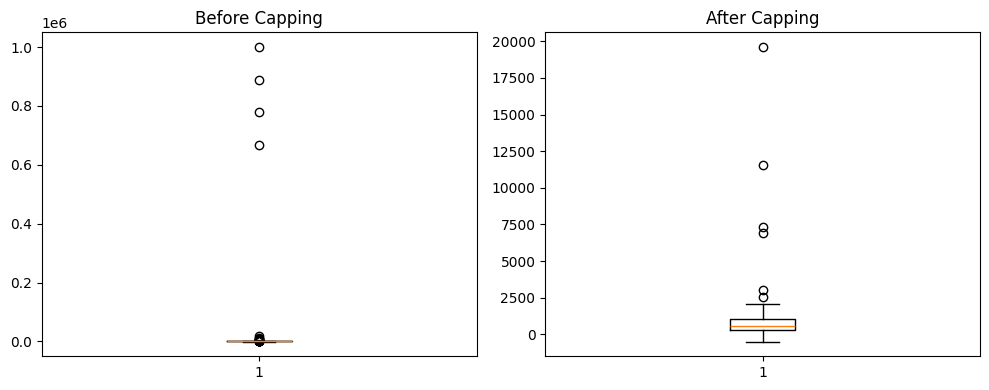

In [7]:
# TODO 6.1: ใช้เฉพาะรายการที่ไม่ใช่โปรโมชัน คำนวณ Q1, Q3, IQR, Lower/Upper Bound
mask_non_promo = df['Is_Promotion'] != 'Y'
non_promo = df.loc[mask_non_promo, 'Transaction_Amount']

Q1 = non_promo.quantile(0.25)
Q3 = non_promo.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}, Lower={lower_bound:.2f}, Upper={upper_bound:.2f}")

# TODO 6.2: สร้าง Outlier Flag ก่อนทำ Capping (เฉพาะรายการที่ไม่ใช่โปรโมชัน)
df['Outlier_Flag'] = False
df.loc[mask_non_promo, 'Outlier_Flag'] = ~df.loc[mask_non_promo, 'Transaction_Amount'].between(lower_bound, upper_bound)
print("Outliers detected (excluding promotions):", df['Outlier_Flag'].sum())

# TODO 6.3: ใช้ .clip() กับ Transaction_Amount เฉพาะรายการที่ไม่ใช่โปรโมชัน
df['Transaction_Amount_Before_Capping'] = df['Transaction_Amount']
df.loc[mask_non_promo, 'Transaction_Amount'] = df.loc[mask_non_promo, 'Transaction_Amount'].clip(lower_bound, upper_bound)

# TODO 6.4: วาด Boxplot ก่อนและหลัง Capping
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].boxplot(df['Transaction_Amount_Before_Capping'].dropna())
axes[0].set_title('Before Capping')
axes[1].boxplot(df['Transaction_Amount'].dropna())
axes[1].set_title('After Capping')
plt.tight_layout()
plt.show()


### คำถาม 5
เพราะเหตุใดข้อมูลที่อยู่นอก IQR Bound จึงไม่จำเป็นต้องเป็นข้อมูลผิดเสมอ? ยกตัวอย่างจาก Dataset นี้

เพราะว่าเป็นข้อมูการซื้อจิง



## 7) Timeliness: ความทันเวลาในการโหลดข้อมูล

In [8]:
# TODO 7: คำนวณ Load_Delay_Hours จาก Order_Date ถึง Load_Timestamp
df['Order_Date_dt'] = pd.to_datetime(df['Order_Date'], errors='coerce')
df['Load_Delay_Hours'] = (df['Load_Timestamp'] - df['Order_Date_dt']).dt.total_seconds() / 3600

df['Late_Load_Flag'] = df['Load_Delay_Hours'] > 24

n_late = df['Late_Load_Flag'].sum()
pct_late = df['Late_Load_Flag'].mean() * 100
print(f"Late loads: {n_late} rows ({pct_late:.1f}%)")


Late loads: 38 rows (6.2%)


## 8) Data Quality Report และ Export

In [9]:
# TODO 8.1: สรุปตัวชี้วัดก่อนและหลัง Cleaning
report = pd.DataFrame({
    'Metric': [
        'Total Rows (raw)', 'Total Rows (clean)',
        'Missing Email (raw)', 'Missing Province (raw)',
        'Exact Duplicates Removed',
        'Invalid Quantity (1-20)',
        'Mismatched Amounts (Accuracy_Flag)',
        'Ambiguous/Invalid Order_Date (Order_Date_Flag)',
        'Outliers Capped (excl. promotions)',
        'Late Loads (>24h)',
        'Invalid Order Status',
    ],
    'Count': [
        len(df_raw), len(df),
        df_raw['Customer_Email'].isnull().sum(), df_raw['Province'].isnull().sum(),
        exact_dupes,
        df['Quantity_Invalid_Flag'].sum(),
        df['Accuracy_Flag'].sum(),
        df['Order_Date_Flag'].sum(),
        df['Outlier_Flag'].sum(),
        df['Late_Load_Flag'].sum(),
        df['Order_Status_Invalid_Flag'].sum(),
    ],
})
print(report)

# TODO 8.2: Export
df.to_csv(OUTPUT_DIR / 'e_commerce_clean.csv', index=False, encoding='utf-8-sig')
report.to_csv(OUTPUT_DIR / 'data_quality_report.csv', index=False, encoding='utf-8-sig')
print("Exported to", OUTPUT_DIR)


                                            Metric  Count
0                                 Total Rows (raw)    630
1                               Total Rows (clean)    612
2                              Missing Email (raw)     50
3                           Missing Province (raw)     12
4                         Exact Duplicates Removed     18
5                          Invalid Quantity (1-20)      3
6               Mismatched Amounts (Accuracy_Flag)     50
7   Ambiguous/Invalid Order_Date (Order_Date_Flag)     84
8               Outliers Capped (excl. promotions)     19
9                                Late Loads (>24h)     38
10                            Invalid Order Status    170
Exported to /content/outputs


In [10]:
from google.colab import files
files.download(str(OUTPUT_DIR / 'e_commerce_clean.csv'))
files.download(str(OUTPUT_DIR / 'data_quality_report.csv'))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9) Reflection
ตอบเป็นย่อหน้าสั้น ๆ
1. ขั้นตอนใดมีความเสี่ยงทำให้ข้อมูลจริงสูญหายมากที่สุด?
2. กฎใดควรนำไปทำ Automation ใน Data Pipeline?
3. หากใช้ Great Expectations คุณจะสร้าง Expectation ใดอย่างน้อย 3 ข้อ?

**แนวคำตอบ (Reflection):**

1. ขั้นตอนที่มีความเสี่ยงทำให้ข้อมูลจริงสูญหายมากที่สุดคือ **การจัดการ Missing Values และ Outlier Capping**
   หากใช้ `dropna()` หรือลบ Outlier แบบไม่พิจารณา Business Context (เช่น ลบรายการโปรโมชันทิ้งเพราะดูเป็นค่าผิดปกติ)
   จะทำให้ Fact rows หายไปจริง ๆ และยอดขายรวมใน Data Warehouse คลาดเคลื่อนอย่างถาวร กู้คืนย้อนหลังได้ยาก

2. กฎที่ควรนำไปทำ Automation ใน Data Pipeline ได้แก่ การ standardize รูปแบบ (Gender, Payment_Method, Order_Status),
   การแปลงชนิดข้อมูลตัวเลข, การตรวจ Quantity range, การคำนวณ Accuracy_Flag จากสูตร Expected_Amount,
   และการคำนวณ Load_Delay_Hours เพื่อ monitor Timeliness แบบต่อเนื่อง เพราะเป็นกฎที่ตายตัว ทดสอบซ้ำได้ และไม่ต้องใช้วิจารณญาณทางธุรกิจเพิ่มเติม

3. หากใช้ Great Expectations สามารถสร้าง Expectation อย่างน้อย 3 ข้อ เช่น
   - `expect_column_values_to_be_between` สำหรับ Quantity (1-20)
   - `expect_column_values_to_be_in_set` สำหรับ Order_Status และ Payment_Method (ชุดค่าที่มาตรฐานแล้ว)
   - `expect_column_values_to_not_be_null` สำหรับ Transaction_Amount และ Order_Date หลัง cleaning


## Checklist ก่อนส่ง
- [ ] Notebook รันจากบนลงล่างได้โดยไม่ Error
- [ ] มีคำตอบคำถามทั้ง 5 ข้อและ Reflection
- [ ] ส่ง `e_commerce_clean.csv`
- [ ] ส่ง `data_quality_report.csv`
- [ ] ไม่ลบรายการโปรโมชันเพียงเพราะเป็น Outlier
